# Student Performance Prediction

Predict whether a student will **Pass or Fail** based on:
- Study hours
- Attendance %
- Previous exam score

Simple, step-by-step demo — one cell per task.


## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


## Step 2: Create the Dataset

500 students, each with random but realistic values.
`results` is our target — starts as text: "Pass" or "Fail".


In [2]:
import numpy as np
np.random.seed(1)

n = 500
study_hours = np.random.randint(1, 10, n)
attendance = np.random.randint(30, 100, n)
past_score = np.random.randint(20, 100, n)

# A student passes if their combined performance crosses a threshold
score = (study_hours * 5) + (attendance * 0.4) + (past_score * 0.4)
results = np.where(score > np.percentile(score, 40), "Pass", "Fail")

df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "past_score": past_score,
    "results": results
})

df.head(10)


,study_hours,attendance,past_score,results
0,6,35,87,Pass
1,9,91,99,Pass
2,6,80,23,Pass
3,1,75,67,Fail
4,1,51,90,Fail
5,2,55,62,Fail
6,8,31,25,Fail
7,7,43,40,Fail
8,3,68,77,Pass
9,5,57,79,Pass


## Step 3: Convert `results` to Numbers

Models need numbers, not text. We map **Pass → 1** and **Fail → 0**,
replacing the same `results` column in place.


In [3]:
df["results"] = df["results"].map({"Pass": 1, "Fail": 0})

df.head(10)


,study_hours,attendance,past_score,results
0,6,35,87,1
1,9,91,99,1
2,6,80,23,1
3,1,75,67,0
4,1,51,90,0
5,2,55,62,0
6,8,31,25,0
7,7,43,40,0
8,3,68,77,1
9,5,57,79,1


## Step 4: Look at the Data

In [4]:
df.describe()


,study_hours,attendance,past_score,results
count,500.000000,500.000000,500.000000,500.000000
mean,4.984000,65.518000,59.916000,0.598000
std,2.612546,19.964339,23.069576,0.490793
min,1.000000,30.000000,20.000000,0.000000
25%,3.000000,50.000000,40.000000,0.000000
50%,5.000000,65.000000,59.500000,1.000000
75%,7.000000,82.250000,79.000000,1.000000
max,9.000000,99.000000,99.000000,1.000000


## Step 5: Visualize — Study Hours vs Results

A quick plot to *see* the pattern before we model it.


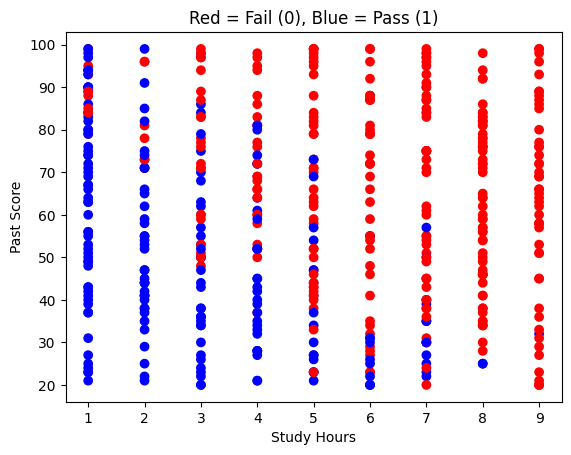

In [5]:
plt.scatter(df["study_hours"], df["past_score"], c=df["results"], cmap="bwr")
plt.xlabel("Study Hours")
plt.ylabel("Past Score")
plt.title("Red = Fail (0), Blue = Pass (1)")
plt.show()


## Step 6: Define Input Features (X) and Target (y)

In [6]:
X = df[["study_hours", "attendance", "past_score"]]
y = df["results"]


## Step 7: Split into Training and Testing Data

We train on most of the data, then test on unseen data to check accuracy.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 350
Testing samples: 150


## Step 8: Train the Model

We use **Logistic Regression** — a standard algorithm for yes/no predictions.


In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained.")


Model trained.


## Step 9: Predict on Test Data

In [9]:
y_pred = model.predict(X_test)

print("Actual:   ", list(y_test))
print("Predicted:", list(y_pred))


Actual:    [1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1]
Predicted: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int

## Step 10: Check Accuracy

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.0f}%")


Accuracy: 100%


## Step 11: Confusion Matrix

Shows how many predictions were correct vs. wrong, broken down by class.


In [11]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[59  0]
 [ 0 91]]


## Step 12: Predict for a New Student

Change these numbers live and re-run this cell.


In [12]:
new_student = pd.DataFrame([{
    "study_hours": 5,
    "attendance": 75,
    "past_score": 60
}])

result = model.predict(new_student)[0]
print("Prediction:", "PASS" if result == 1 else "FAIL")


Prediction: PASS


## Summary

1. Loaded student data (study hours, attendance, past score)
2. Visualized the pattern
3. Trained a Logistic Regression model
4. Tested accuracy on unseen data
5. Predicted outcome for a new student

**Extension idea:** try `LinearRegression` instead, to predict the exact
score instead of just Pass/Fail.
